In [9]:
from glob import glob
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

agentic_4k_c.log 91.0 72.0
agentic_8k_c.log 235.0 132.0
agentic_8k_d.log 303.0 119.0
agentic_4k_d.log 132.0 74.0
rlvr_4k_c.log 59.0 63.0
rlvr_8k_c.log 92.0 102.0
rlvr_8k_d.log 126.0 107.0
rlvr_4k_d.log 73.0 74.0


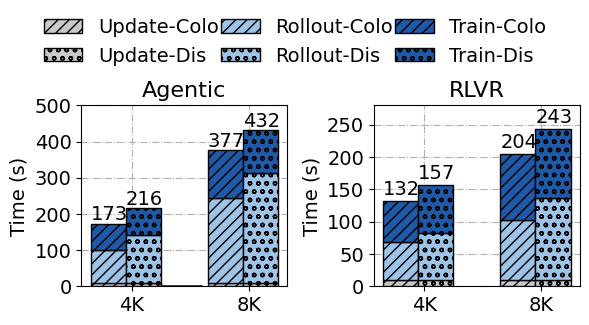

In [80]:
def parse_phase_time(file: str, job_name: str, log_type='sched'):
    with open(file, 'r') as f:
        content = f.read().split("\n")
    ts = {phase: [] for phase in ['generate', 'train']}
    te = {phase: [] for phase in ['generate', 'train']}
    t_busy = {phase: [] for phase in ['generate', 'train']}
    for line in content:
        for phase in ['generate', 'train']:
            pattern_start = f"Event(job={job_name}, phase={phase}, type=status, value=running"
            pattern_end = f"Event(job={job_name}, phase={phase}, type=done"
            if pattern_start in line:
                t = datetime.strptime(line.split(" |")[0], '%Y/%m/%d %H:%M:%S') if log_type == "sched" else datetime.strptime(line[:len("[2025-10-10 15:57:12]")], '[%Y-%m-%d %H:%M:%S]')
                ts[phase].append(t)
            if pattern_end in line:
                t = datetime.strptime(line.split(" |")[0], '%Y/%m/%d %H:%M:%S') if log_type == "sched" else datetime.strptime(line[:len("[2025-10-10 15:57:12]")], '[%Y-%m-%d %H:%M:%S]')
                te[phase].append(t)
    for phase in ['generate', 'train']:
        assert len(ts[phase]) == len(te[phase])
        t_busy[phase] = [(te[phase][i] - ts[phase][i]).total_seconds() for i in range(len(ts[phase]))]
    if len(t_busy[phase]) == 0:
        return 0, 0
    return [np.min(t_busy[phase]) for phase in ['generate', 'train']]

t_update = 10
bar_width = 0.3
colors = ["#C9C9C9", "#9DC3E6", "#1E5AA8"]
plt.figure(figsize=(6, 3))
axlist = [plt.subplot(1, 2, i + 1) for i in range(2)]
axs = {"agentic": axlist[0], "rlvr": axlist[1]}
for filename in glob("*.log"):
    workload, length, colodis = filename.strip(".log").split("_")
    t_roll, t_train = parse_phase_time(filename, "job1", "sched" if ('agentic' in filename or '_d' in filename) else 'manual')
    print(filename, t_roll, t_train)
    idx = (0 if length == '4k' else 1) + (0 if colodis == 'c' else bar_width)
    hatch = '///' if colodis == 'c' else 'oo'
    axs[workload].bar([idx], t_update, width=bar_width, color=colors[0], edgecolor='black', hatch=hatch, zorder=100)
    axs[workload].bar([idx], t_roll, bottom=t_update, width=bar_width, color=colors[1], edgecolor='black', hatch=hatch, zorder=100)
    axs[workload].bar([idx], t_train, bottom=t_update + t_roll, width=bar_width, color=colors[2], edgecolor='black', hatch=hatch, zorder=100)
    axs[workload].text(idx - 0.15, t_update + t_roll + t_train + 10, f"{t_update + t_roll + t_train:.0f}", fontdict={"fontsize": 14})

labels = ['Update', 'Rollout', 'Train']
for i in range(len(colors)):
    axlist[0].bar([0.4], 0, color=colors[i], edgecolor='black', hatch='///', zorder=0, label=f'{labels[i]}-Colo')
    axlist[0].bar([0.4], 0, color=colors[i], edgecolor='black', hatch='oo', zorder=0, label=f'{labels[i]}-Dis')

for (name, ax) in axs.items():
    plt.sca(ax)
    plt.yticks(fontsize=14)
    ax.set_xticks([0.2, 1.2], ["4K", "8K"], fontsize=14)
    ax.set_ylabel("Time (s)", fontdict={"fontsize": 14})
    ax.set_title('RLVR' if name == 'rlvr' else 'Agentic', fontdict={"fontsize": 16})
    ax.grid(linestyle='-.')
axlist[0].set_ylim(0, 500)
axlist[1].set_ylim(0, 280)
lgd = plt.figlegend(ncols=3, loc='upper center', bbox_to_anchor=(0.5, 1.1), fontsize=14, columnspacing=0.1, frameon=False)
plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.savefig("motivation_breakdown.pdf", bbox_extra_artists=(lgd,), bbox_inches='tight')